# Exploratory Data Analysis DIASource

**Goals**
1) Plot raw and smoothed light curves to visualize brightness changes over time
3) Prepare for period estimation using models like Lomb-Scargle
3) Detect variable stars "pulsing" over time-tracking
4) Estimate period and amplitude
5) Classify stars using astronomy, data science, data analytics, and statistics

---

**Core Columns**

`coord_ra`, `coord_dec`, `midPointTai`, `psFlux`, `psFluxErr`, `filterName`,  
`psfFlux_flag`, `psfFlux_flag_edge`, `psfFlux_flag_noGoodPixels`,  
`diaObjectId`, `diaSourceId`

---

**Summary Table**

| Metric / Field             | Description                                                   |
|----------------------------|---------------------------------------------------------------|
| `coord_ra`, `coord_dec`    | Right Ascension and Declination (ICRS)                        |
| `midPointMjdTai`              | Time of observation in TAI                                    |
| `psfFlux`, `psfFluxErr`      | PSF flux and flux uncertainty for each observation            |
| `filterName`               | LSST filter used (e.g. g, r, i)                               |
| `psfFlux_flag`            | Quality control flags for removing unreliable measurements    |
| `diaObjectId`              | Foreign key to group detections into single light curves      |
| `diaSourceId`              | Unique ID for each observation                               |

---

**Tasks**
1) Plot midPointTai vs psFlux with psFluxErr as error bars Light Curving Plotting

In [37]:
# libraries, imports, etc
import numpy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import random
from matplotlib import colormaps
import seaborn as sns

print('numpy version: ', numpy.__version__)
print('matplotlib version: ', matplotlib.__version__)

numpy version:  2.2.6
matplotlib version:  3.10.3


In [9]:
# TAP Service 
from lsst.rsp import get_tap_service, retrieve_query

service = get_tap_service("tap")
assert service is not None

We start using functions from here because DiaObject was doing single-snapshot metadata checks,but we need to start breaking it down per object since we are going to do time series data per object, aka light curves. We need to repeat this same analysis for many stars and functions will help make that repeatable and modular, where we just pass a different ```object_id```.

In [28]:
# midPointTai vs psFlux (psFluxErr error bars) - Light Curve Plotting
def plot_light_curve(df, object_id):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointMjdTai')
    plt.errorbar(obj_df['midPointMjdTai'], obj_df['psfFlux'], yerr=obj_df['psfFluxErr'], fmt='o', alpha=0.6)
    plt.xlabel('midPointMjdTai')
    plt.ylabel('psfFlux')
    plt.title(f'Light Curve for objectId {object_id}')
    plt.grid(True)
    plt.show()

2) Compute and plot rolling mean to visualize periodic patterns

In [29]:
# Rolling Mean Smoothing 
def plot_rolling_mean(df, object_id, window=5):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointMjdTai')
    obj_df['rolling_psfFlux'] = obj_df['psfFlux'].rolling(window=window, center=True).mean()
    
    plt.plot(obj_df['midPointMjdTai'], obj_df['psfFlux'], 'o', alpha=0.4, label='Raw Flux')
    plt.plot(obj_df['midPointMjdTai'], obj_df['rolling_psfFlux'], '-', label=f'Rolling Mean (window={window})')
    plt.xlabel('midPointMjdTai')
    plt.ylabel('psfFlux')
    plt.title(f'Rolling Mean Light Curve for objectId {object_id}')
    plt.legend()
    plt.grid(True)
    plt.show()

**Object Table**

These are some simple metadata checks to help ensure data consistency and support downstream classification 
1) RA vs Dec scatter plot to verify spatial coverage

In [30]:
# RA vs Dec 
def plot_spatial_coverage(object_df):
    plt.scatter(object_df['coord_ra'], object_df['coord_dec'], s=1, alpha=0.5)
    plt.xlabel('RA')
    plt.ylabel('Dec')
    plt.title('Sky Position: RA vs Dec')
    plt.grid(True)
    plt.show()

2) Observation Density Check
Histogram of number of observations per star (use objectID groupby count) to identify stars with enough observations for reliable variability or period analysis

In [31]:
# Number of Observations per Star
def plot_observation_logdensity(diasource_df):
    counts = diasource_df.groupby('diaObjectId').size()
    plt.hist(counts, bins=30, log=True)
    plt.xlabel('Number of Observations')
    plt.ylabel('Number of Stars')
    plt.title('Observation Density per Star (Log Scale)')
    plt.grid(True)
    plt.show()

def plot_observation_density(diasource_df):
    counts = diasource_df.groupby('diaObjectId').size()
    plt.hist(counts, bins=30)
    plt.xlabel('Number of Observations')
    plt.ylabel('Number of Stars')
    plt.title('Observation Density per Star')
    plt.grid(True)
    plt.show()

3) Time Gaps Between Observations - Histograms of time deltas between successive midPointTai values per object (irregular sampling impacts period finding and reveals cadence issues, observational gaps, or survey artifacts) 

In [32]:
# Histogram of time deltas vs midPointTai
def plot_time_deltas(df, object_id):
    obj_df = df[df['diaObjectId'] == object_id].sort_values('midPointMjdTai')
    deltas = np.diff(obj_df['midPointMjdTai'])
    plt.hist(deltas, bins=20)
    plt.xlabel('Time Gap (days)')
    plt.ylabel('Frequency')
    plt.title(f'Time Gaps Between Observations for objectId {object_id}')
    plt.grid(True)
    plt.show()

4) Flux Distribution Histogram of psFlux Values (identifies measurement bias, outliers, saturation, and can be log scaled or split by variability classes)

In [33]:
# Histogram
def plot_flux_logdistribution(df, object_id=None):
    if object_id:
        df = df[df['diaObjectId'] == object_id]
    plt.hist(df['psfFlux'], bins=50, log=True)
    plt.xlabel('psfFlux')
    plt.ylabel('Count')
    plt.title(f'Flux Distribution {"(Log Scale)" }')
    plt.grid(True)
    plt.show()

def plot_flux_distribution(df, object_id=None):
    if object_id:
        df = df[df['diaObjectId'] == object_id]
    plt.hist(df['psfFlux'], bins=50)
    plt.xlabel('psfFlux')
    plt.ylabel('Count')
    plt.title(f'Flux Distribution')
    plt.grid(True)
    plt.show()

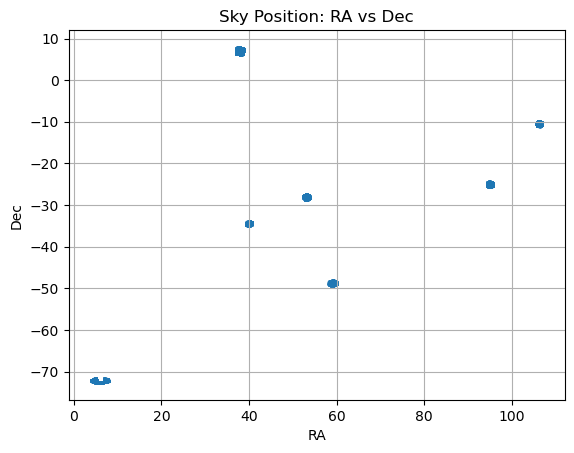

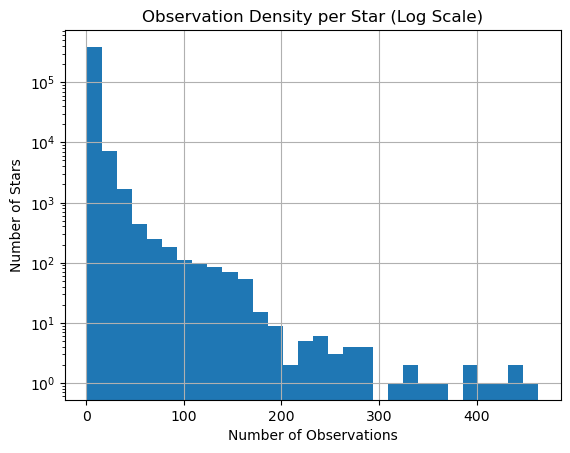

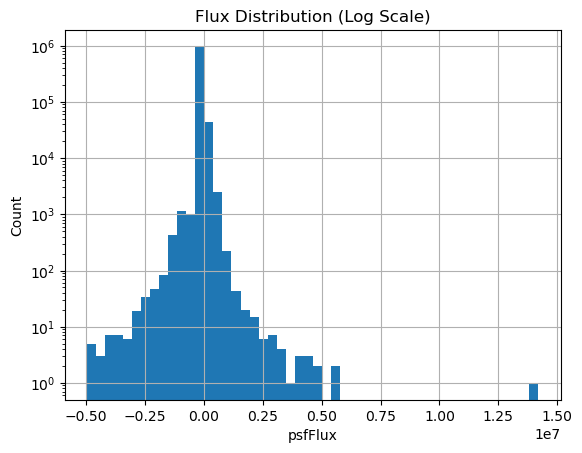

Plotting for objectId: 648371424100089875


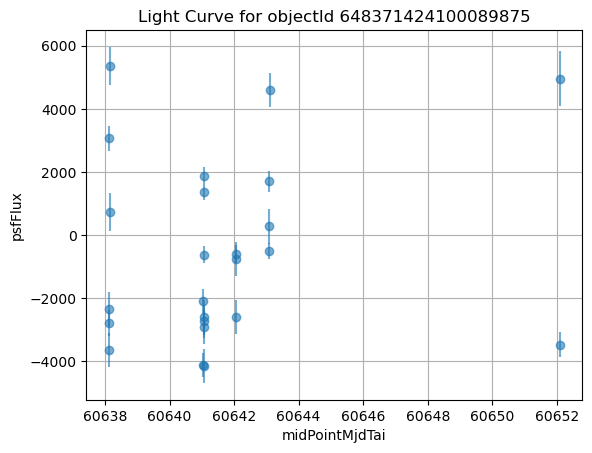

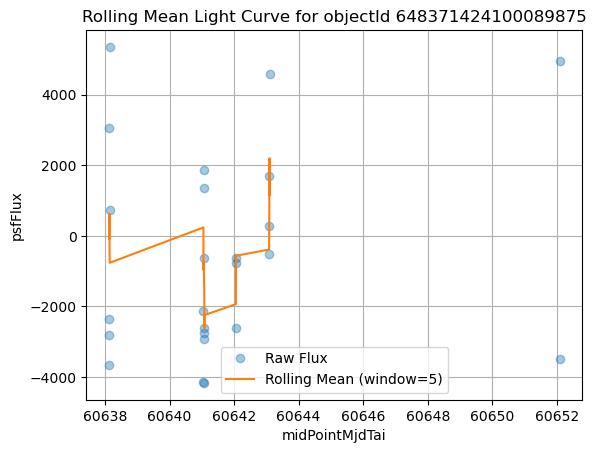

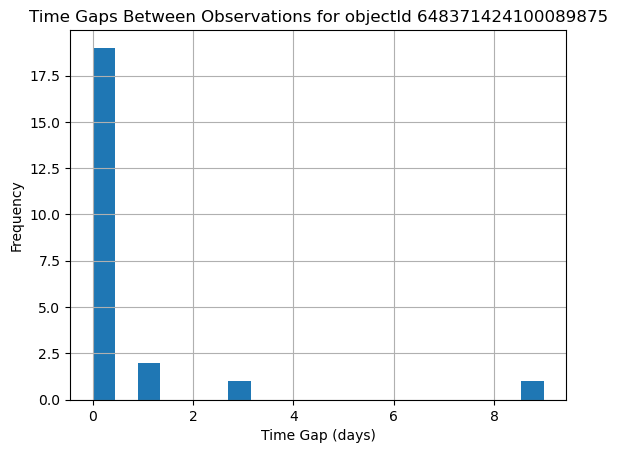

Plotting for objectId: 604063441962926186


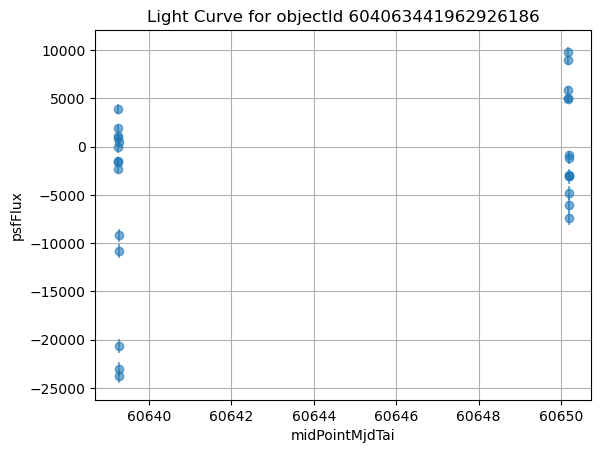

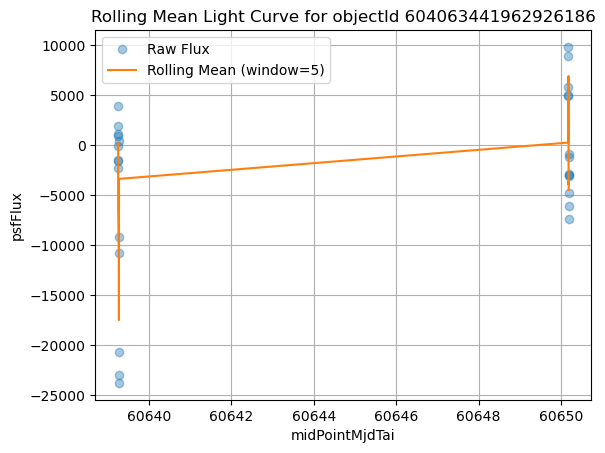

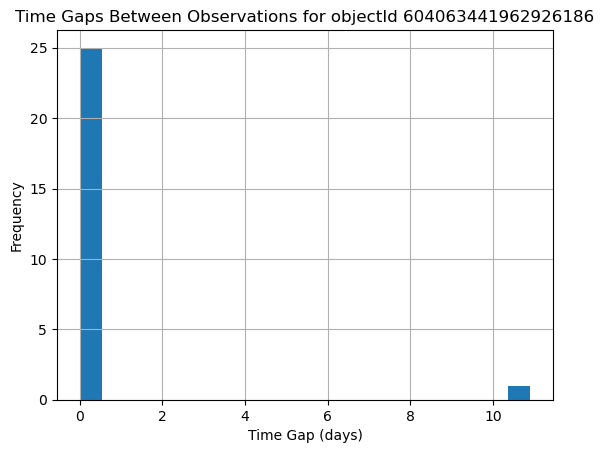

Plotting for objectId: 579585358191132744


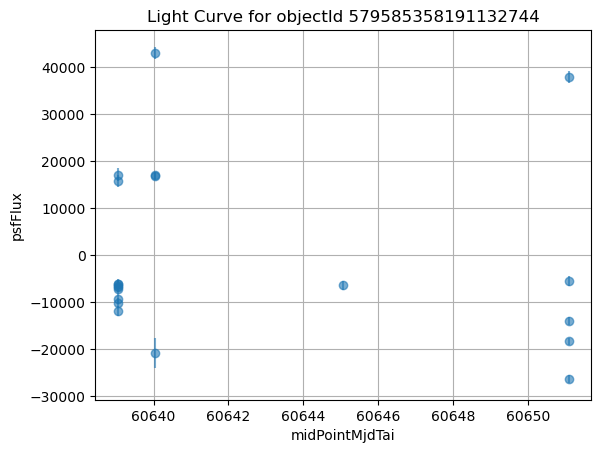

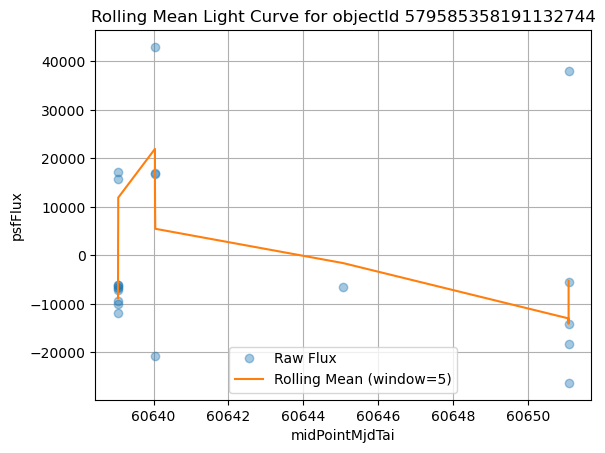

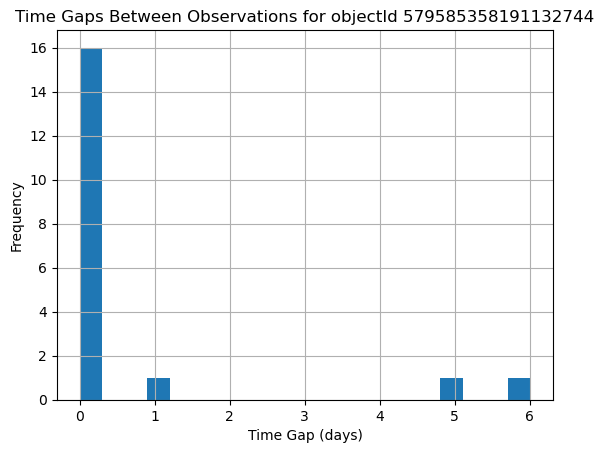

Plotting for objectId: 604062754768158925


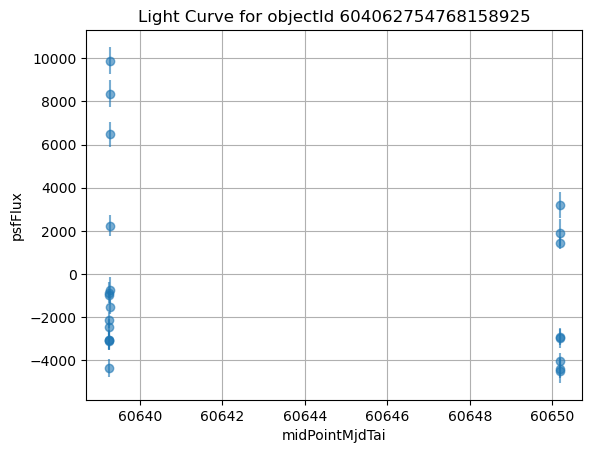

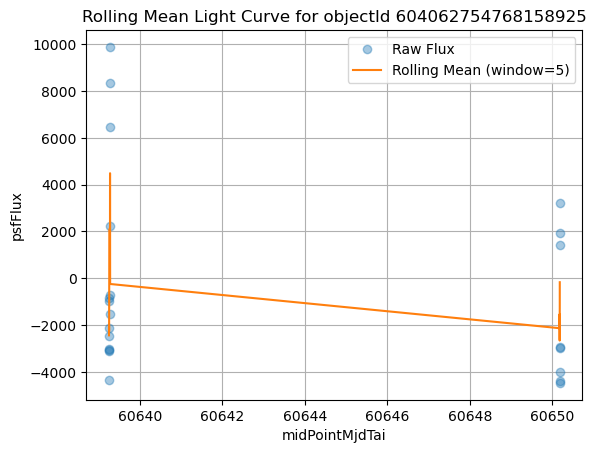

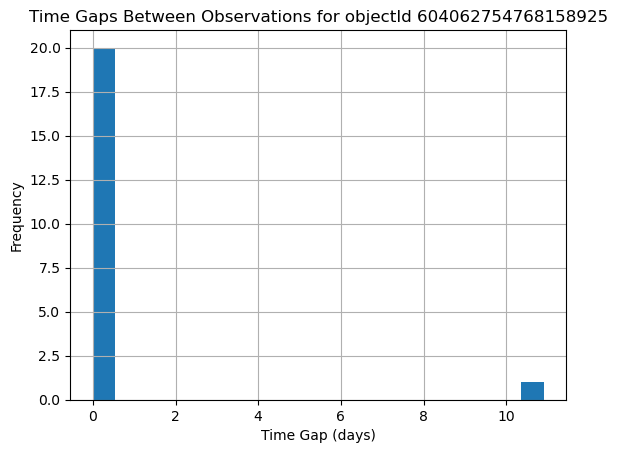

Plotting for objectId: 614438296243666970


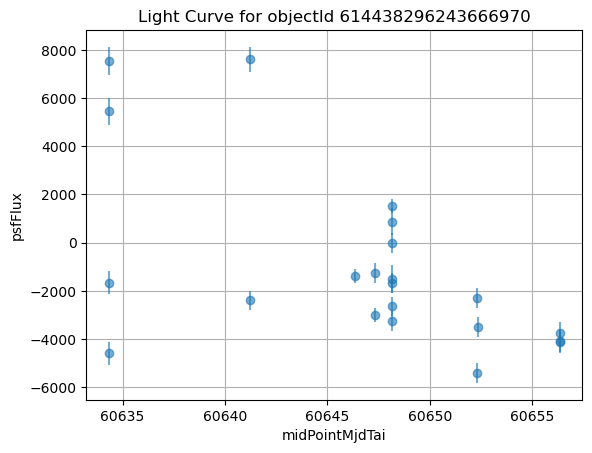

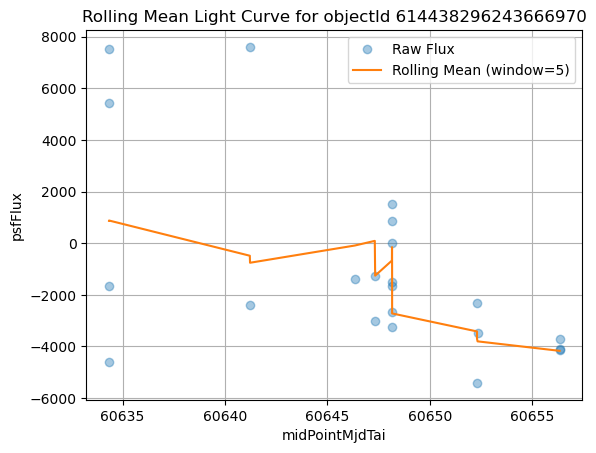

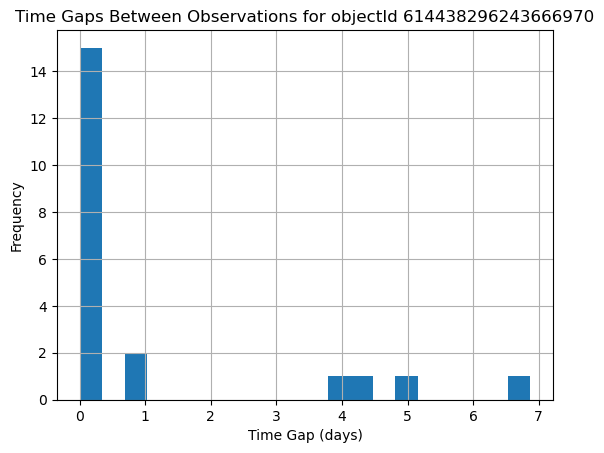

In [38]:
# Testing

counts = diasource_df['diaObjectId'].value_counts()
enough_obs_ids = counts[counts >= 20].index.tolist()

random_ids = random.sample(enough_obs_ids, k=5)

plot_spatial_coverage(diasource_df)
plot_observation_logdensity(diasource_df)
plot_flux_logdistribution(diasource_df, object_id=None)
for object_id in random_ids:
    print(f"Plotting for objectId: {object_id}")
    plot_light_curve(diasource_df, object_id)
    plot_rolling_mean(diasource_df, object_id)
    plot_time_deltas(diasource_df, object_id)

counts = diasource_df['diaObjectId'].value_counts()
enough_obs_ids = counts[counts >= 20].index.tolist()

## Findings

- Light curves show clear flux variation over time, with visually distinct patterns in g/r/i filters for candidate variable stars.
- Smoothing via rolling means enhances periodicity and helps distinguish RR Lyrae-like pulsations.
- Many sources show irregular observation cadence, evidenced by time gap histograms with clustered and sparse intervals.
- The flux distribution is heavily right-skewed, indicating a large population of faint sources and a long tail of bright/high-variability candidates.
- Stars with ≥20 observations form a reliable subset for period analysis using tools like Lomb-Scargle.
- Observation density and flux jump tests help flag outliers, missed calibrations, or single-epoch anomalies.

## Summary

The `DiaSource` table contains time-series photometric measurements crucial for detecting and characterizing variable stars. This EDA focused on visualizing flux variability, validating data quality, and preparing inputs for future period finding and classification.

Key steps included:
- Light curve plotting (raw and smoothed)
- Spatial and temporal consistency checks
- Observation density and time gap histograms
- Flux distribution and artifact detection
- Grouping by `diaObjectId` to enable scalable per-star analysis

This builds a foundation for downstream modeling such as Lomb-Scargle periodograms, template fitting, and ML classification.

## Results & Interpretations

- High-confidence variable stars exhibit repeating light curve patterns with amplitudes visible in smoothed flux curves.
- Many candidates meet quality control thresholds: clean flags, ≥20 observations, multiple filters.
- Periodic signals are observable in stars with dense, regular time coverage.
- Observation gaps and flux spikes highlight the importance of flag filtering and cadence-aware methods.
- Cleaned and prepped `DiaSource` light curves are now ready for period estimation and further feature extraction.
